<h3> Tarea: Evaluación difusa de riesgo crediticio</h3>
</div>

#### Objetivo

Construir y analizar un sistema de inferencia colectiva para estimar el **riesgo crediticio**, utilizando datos reales del dataset  
**German Credit Dataset** (UCI Machine Learning Repository).

El dataset contiene información de solicitantes de crédito, incluyendo:

- duración del crédito  
- monto del préstamo  
- historial crediticio  
- empleo  
- nivel de ahorro  
- estado personal  

Variable objetivo: **Riesgo**

#### Tareas:

- Crear agentes con modelos diferentes modelos difusos (Mamdani, Tsukamoto, TSK) para resolver el problema
- Generar la solución global. **Bonus**: Generar una solución que tome en cuenta la reputación como analista de cada agente.
- Discutir resultados. 

#### Entregables

- Notebook reproducible  
- Tabla comparativa (diferentes modelos contra solución teórica y contra solución global)
- Discusión técnica  

---

**Modelos implementados:**
- **Agente 1 – Mamdani:** Sistema clásico con conjuntos difusos lingüísticos
- **Agente 2 – Tsukamoto:** Funciones de membresía monotónicas inversas
- **Agente 3 – TSK (Takagi-Sugeno-Kang):** Consecuentes funcionales lineales

**Solución colectiva:**
- Promedio simple (ensemble)
- Promedio ponderado por reputación (Bonus)


## 1. Importaciones y Configuración

In [167]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import MinMaxScaler
import warnings 
warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
sns.set_palette("husl")
print("✅ Librerías cargadas correctamente")
print(f"   skfuzzy v{fuzz.__version__}  |  numpy v{np.__version__}  |  pandas v{pd.__version__}")


✅ Librerías cargadas correctamente
   skfuzzy v0.5.0  |  numpy v2.4.4  |  pandas v3.0.3


## 2. Carga y Exploración del Dataset


In [168]:
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

df = pd.read_csv(URL, sep=' ', header=None)

# Target
df['risk'] = df[20]

df.drop(columns=[20], inplace=True)

print(df.shape)
df.head()

(1000, 21)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [169]:
selected_cols = [
    'duration',
    'credit_history',
    'purpose',
    'credit_amount',
    'risk'
]

df = df[[1, 2, 3, 4, 'risk']].copy()

df.columns = selected_cols

credit_history_map = {
    'A30': 'no_credits_all_paid',
    'A31': 'all_paid_bank',
    'A32': 'current_paid',
    'A33': 'past_delay',
    'A34': 'critical_account'
}

purpose_map = {
    'A40': 'new_car',
    'A41': 'used_car',
    'A42': 'furniture_equipment',
    'A43': 'radio_tv',
    'A44': 'domestic_appliances',
    'A45': 'repairs',
    'A46': 'education',
    'A47': 'vacation',
    'A48': 'retraining',
    'A49': 'business',
    'A410': 'others'
}
df['credit_history'] = (
    df['credit_history']
    .map(credit_history_map)
)

df['purpose'] = (
    df['purpose']
    .map(purpose_map)
)
df['risk'] = df['risk'].map({1: 0, 2: 1})  # 0: Bajo Riesgo, 1: Alto Riesgo


df.head()

,duration,credit_history,purpose,credit_amount,risk
0,6,critical_account,radio_tv,1169,0
1,48,current_paid,radio_tv,5951,1
2,12,critical_account,education,2096,0
3,42,current_paid,furniture_equipment,7882,0
4,24,past_delay,new_car,4870,1


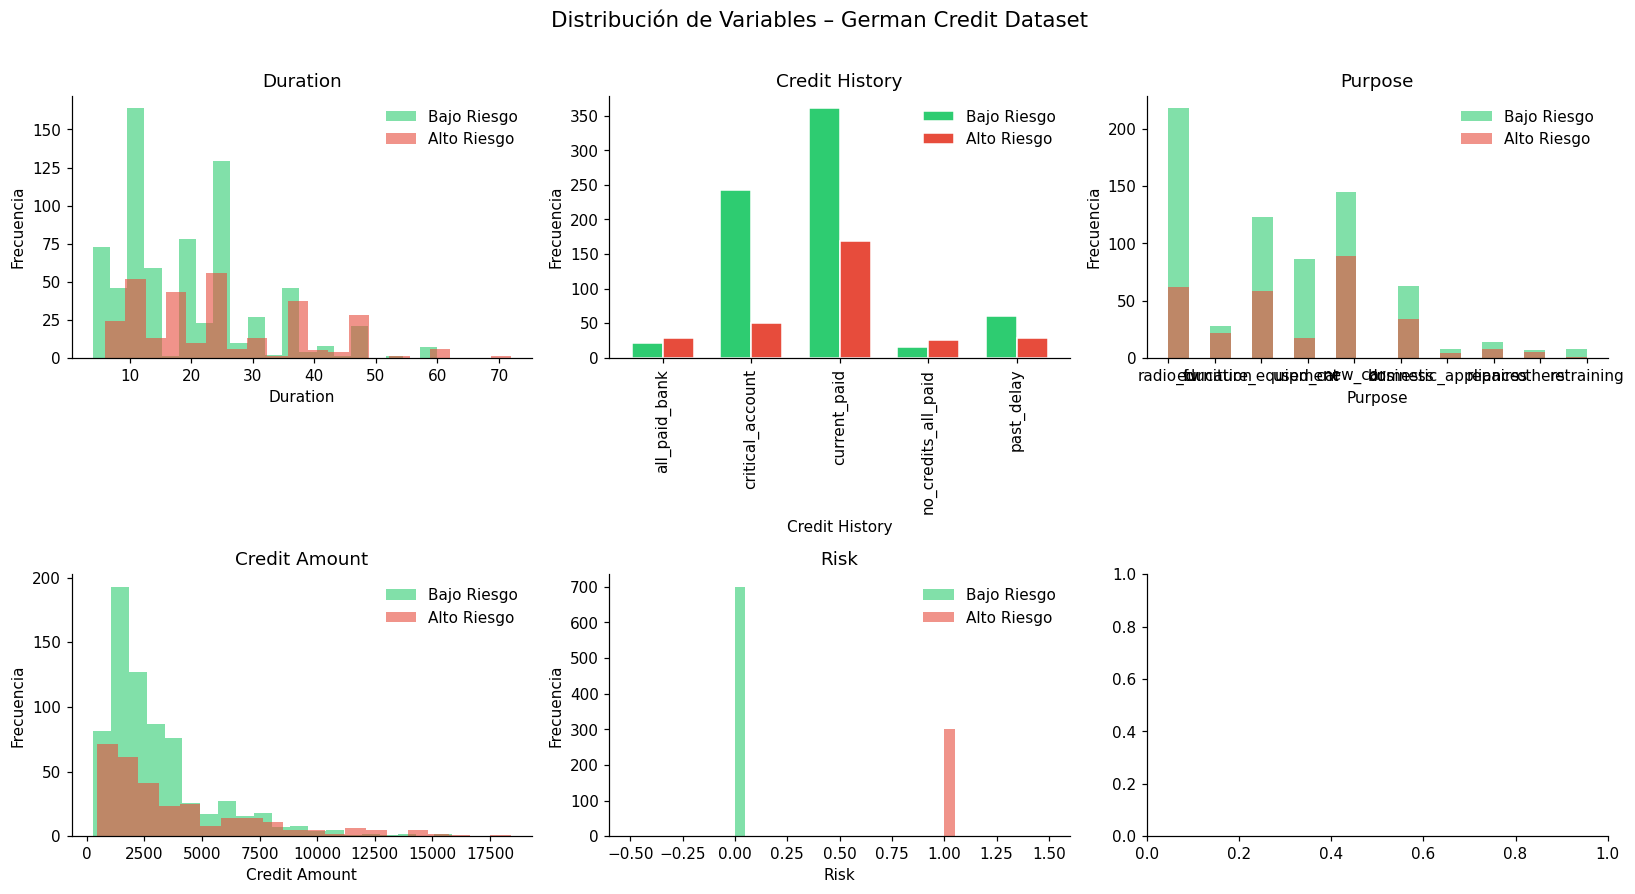

✅ EDA guardado


In [170]:
# ── Visualización exploratorio ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de Variables – German Credit Dataset', fontsize=14, y=1.01)

features = df.columns.tolist()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for ax, feat, col in zip(axes.flat, features, colors):
    if feat in ['credit_history','employment','savings']:
        counts = df.groupby([feat,'risk']).size().unstack(fill_value=0)
        counts.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], 
                    edgecolor='white', width=0.7)
        ax.set_xlabel(feat.replace('_',' ').title())
        ax.set_ylabel('Frecuencia')
        ax.legend(['Bajo Riesgo','Alto Riesgo'], frameon=False)
    else:
        for risk_val, grp in df.groupby('risk'):
            label = 'Bajo Riesgo' if risk_val==0 else 'Alto Riesgo'
            color = '#2ecc71' if risk_val==0 else '#e74c3c'
            ax.hist(grp[feat], bins=20, alpha=0.6, color=color, label=label, edgecolor='none')
        ax.set_xlabel(feat.replace('_',' ').title())
        ax.set_ylabel('Frecuencia')
        ax.legend(frameon=False)
    ax.set_title(feat.replace('_',' ').title())

plt.tight_layout()
plt.show()
print("✅ EDA guardado")


## 3. Preprocesamiento – Normalización de Variables de Entrada

In [171]:
scaler = MinMaxScaler()

df[['duration_norm',
    'credit_amount_norm']] = scaler.fit_transform(
    df[['duration', 'credit_amount']]
)

In [172]:
credit_history_score = {
    'no_credits_all_paid': 0.2,
    'all_paid_bank': 0.3,
    'current_paid': 0.5,
    'past_delay': 0.8,
    'critical_account': 1.0
}

df['credit_history_score'] = (
    df['credit_history']
    .map(credit_history_score)
)

purpose_score = {
    'new_car': 0.4,
    'used_car': 0.5,
    'furniture_equipment': 0.4,
    'radio_tv': 0.3,
    'domestic_appliances': 0.4,
    'repairs': 0.6,
    'education': 0.7,
    'vacation': 0.8,
    'retraining': 0.6,
    'business': 0.9,
    'others': 0.5
}

df['purpose_score'] = (
    df['purpose']
    .map(purpose_score)
)


df.head()

,duration,credit_history,purpose,credit_amount,risk,duration_norm,credit_amount_norm,credit_history_score,purpose_score
0,6,critical_account,radio_tv,1169,0,0.029412,0.050567,1.0,0.3
1,48,current_paid,radio_tv,5951,1,0.647059,0.313690,0.5,0.3
2,12,critical_account,education,2096,0,0.117647,0.101574,1.0,0.7
3,42,current_paid,furniture_equipment,7882,0,0.558824,0.419941,0.5,0.4
4,24,past_delay,new_car,4870,1,0.294118,0.254209,0.8,0.4


## 4. Agente 1 – Sistema Mamdani


### Variables lingüísticas
- **Entrada:** duration_norm, credit_amount_norm, credit_history_score, purpose_score
- **Salida:** `riesgo` ∈ [0, 1] (0 = muy bajo, 1 = muy alto)


In [173]:
# =====================================================
# AGENTE 1: MAMDANI
# =====================================================

duration = ctrl.Antecedent(np.arange(0,1.01,0.01), 'duration')
credit_amount = ctrl.Antecedent(np.arange(0,1.01,0.01), 'credit_amount')
credit_history = ctrl.Antecedent(np.arange(0,1.01,0.01), 'credit_history')
purpose = ctrl.Antecedent(np.arange(0,1.01,0.01), 'purpose')

risk = ctrl.Consequent(np.arange(0,1.01,0.01), 'risk')

# Duration
duration['short'] = fuzz.trimf(duration.universe,[0,0,0.4])
duration['medium'] = fuzz.trimf(duration.universe,[0.2,0.5,0.8])
duration['long'] = fuzz.trimf(duration.universe,[0.6,1,1])

# Amount
credit_amount['low'] = fuzz.trimf(credit_amount.universe,[0,0,0.4])
credit_amount['medium'] = fuzz.trimf(credit_amount.universe,[0.2,0.5,0.8])
credit_amount['high'] = fuzz.trimf(credit_amount.universe,[0.6,1,1])

# History
credit_history['good'] = fuzz.trimf(credit_history.universe,[0,0,0.4])
credit_history['average'] = fuzz.trimf(credit_history.universe,[0.2,0.5,0.8])
credit_history['bad'] = fuzz.trimf(credit_history.universe,[0.6,1,1])

# Purpose
purpose['safe'] = fuzz.trimf(purpose.universe,[0,0,0.4])
purpose['moderate'] = fuzz.trimf(purpose.universe,[0.2,0.5,0.8])
purpose['risky'] = fuzz.trimf(purpose.universe,[0.6,1,1])

# OUTPUT BINARIO
risk['low'] = fuzz.trimf(risk.universe,[0,0,0.5])
risk['high'] = fuzz.trimf(risk.universe,[0.5,1,1])

rules = [

    ctrl.Rule(credit_history['bad'],
              risk['high']),

    ctrl.Rule(duration['long'] &
              credit_amount['high'],
              risk['high']),

    ctrl.Rule(credit_history['good'] &
              credit_amount['low'],
              risk['low']),

    ctrl.Rule(duration['short'] &
              credit_history['good'],
              risk['low']),

    ctrl.Rule(credit_amount['medium'] &
              credit_history['average'],
              risk['high']),

    ctrl.Rule(purpose['risky'] &
              credit_amount['high'],
              risk['high']),

    ctrl.Rule(purpose['safe'] &
              credit_history['good'],
              risk['low']),

    ctrl.Rule(duration['long'] &
              credit_history['average'],
              risk['high']),

    ctrl.Rule(credit_amount['high'] &
              credit_history['average'],
              risk['high']),

    ctrl.Rule(duration['medium'] &
              credit_amount['medium'] &
              credit_history['average'],
              risk['low'])
]

mamdani_ctrl = ctrl.ControlSystem(rules)

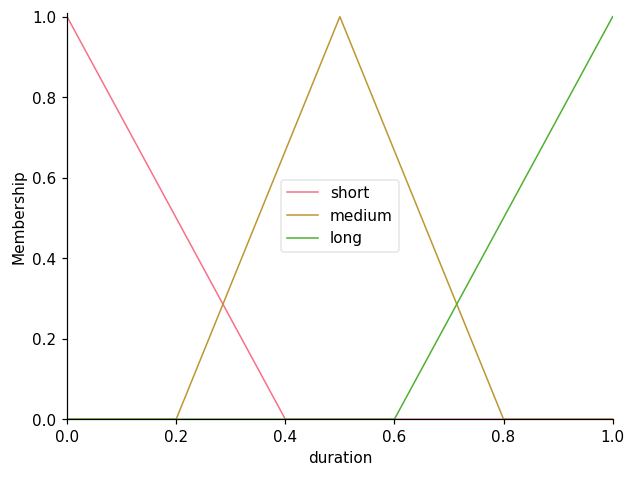

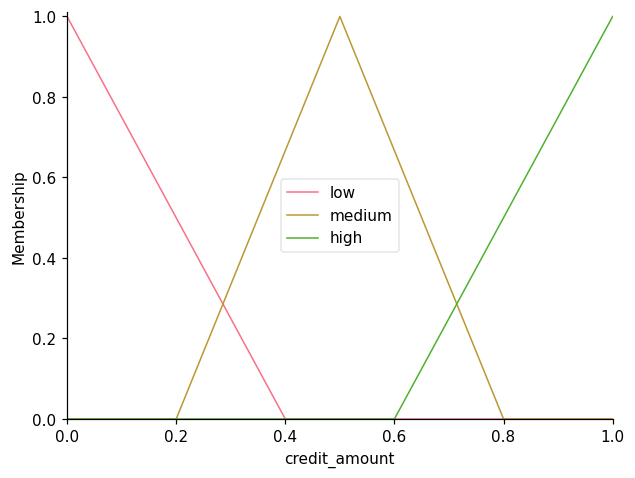

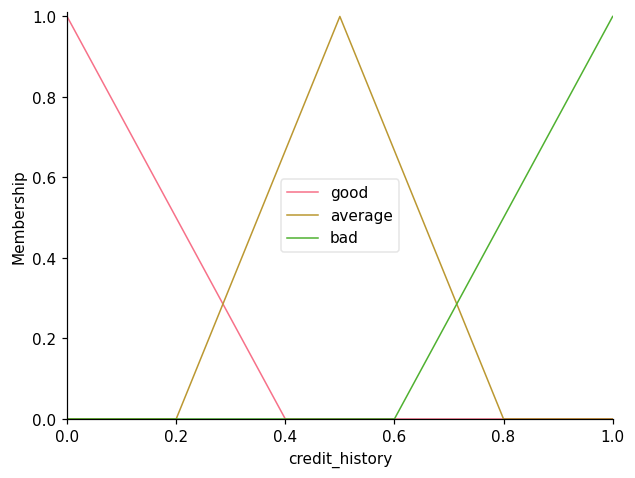

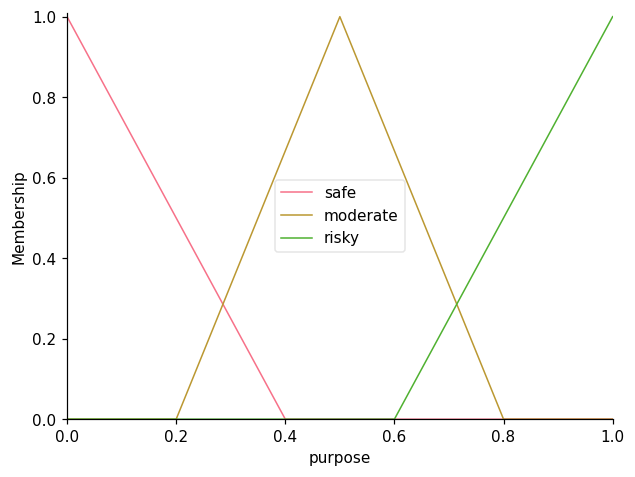

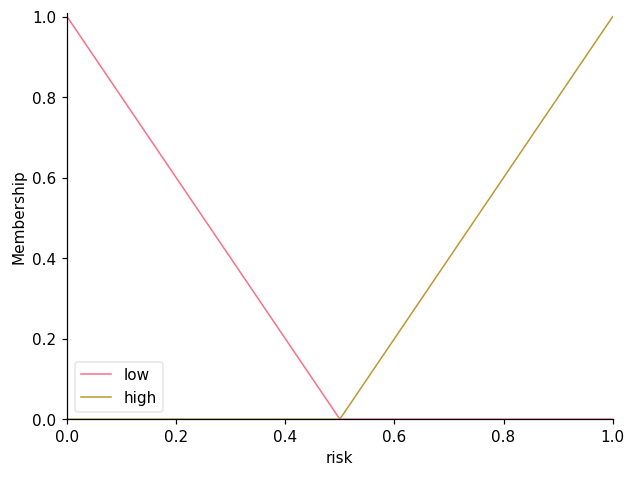

In [174]:
duration.view()
credit_amount.view()
credit_history.view()
purpose.view()
risk.view()
plt.show()

## 5. Agente 2 – Sistema Tsukamoto


In [175]:
# =====================================================
# AGENTE 2: TSUKAMOTO
# =====================================================

def triangular(x,a,b,c):

    if x <= a or x >= c:
        return 0

    elif x <= b:
        return (x-a)/(b-a)

    else:
        return (c-x)/(c-b)


def low_inverse(alpha):
    return 1-alpha


def high_inverse(alpha):
    return alpha

In [176]:
def tsukamoto_predict(row):

    d = row['duration_norm']
    a = row['credit_amount_norm']
    h = row['credit_history_score']
    p = row['purpose_score']

    short = triangular(d,0,0.2,0.4)
    medium_d = triangular(d,0.2,0.5,0.8)
    long = triangular(d,0.6,0.8,1)

    low = triangular(a,0,0.2,0.4)
    medium_a = triangular(a,0.2,0.5,0.8)
    high = triangular(a,0.6,0.8,1)

    good = triangular(h,0,0.2,0.4)
    average = triangular(h,0.2,0.5,0.8)
    bad = triangular(h,0.6,0.8,1)

    safe = triangular(p,0,0.2,0.4)
    moderate = triangular(p,0.2,0.5,0.8)
    risky = triangular(p,0.6,0.8,1)

    alphas = []
    zs = []

    # R1
    alpha = bad
    alphas.append(alpha)
    zs.append(high_inverse(alpha))

    # R2
    alpha = min(long, high)
    alphas.append(alpha)
    zs.append(high_inverse(alpha))

    # R3
    alpha = min(good, low)
    alphas.append(alpha)
    zs.append(low_inverse(alpha))

    # R4
    alpha = min(short, good)
    alphas.append(alpha)
    zs.append(low_inverse(alpha))

    # R5
    alpha = min(medium_a, average)
    alphas.append(alpha)
    zs.append(high_inverse(alpha))

    # R6
    alpha = min(risky, high)
    alphas.append(alpha)
    zs.append(high_inverse(alpha))

    # R7
    alpha = min(safe, good)
    alphas.append(alpha)
    zs.append(low_inverse(alpha))

    # R8
    alpha = min(long, average)
    alphas.append(alpha)
    zs.append(high_inverse(alpha))

    # R9
    alpha = min(high, average)
    alphas.append(alpha)
    zs.append(high_inverse(alpha))

    # R10
    alpha = min(medium_d, medium_a, average)
    alphas.append(alpha)
    zs.append(low_inverse(alpha))

    alphas = np.array(alphas)
    zs = np.array(zs)

    if alphas.sum() == 0:
        return 0.5

    return np.sum(alphas*zs)/np.sum(alphas)

## 6. Agente 3 – Sistema TSK (Takagi-Sugeno-Kang, Orden 1)


In [177]:
# =====================================================
# AGENTE 3: TSK
# =====================================================

def tsk_predict(row):

    d = row['duration_norm']
    a = row['credit_amount_norm']
    h = row['credit_history_score']
    p = row['purpose_score']

    short = triangular(d,0,0.2,0.4)
    medium_d = triangular(d,0.2,0.5,0.8)
    long = triangular(d,0.6,0.8,1)

    low = triangular(a,0,0.2,0.4)
    medium_a = triangular(a,0.2,0.5,0.8)
    high = triangular(a,0.6,0.8,1)

    good = triangular(h,0,0.2,0.4)
    average = triangular(h,0.2,0.5,0.8)
    bad = triangular(h,0.6,0.8,1)

    safe = triangular(p,0,0.2,0.4)
    risky = triangular(p,0.6,0.8,1)

    rules = [

        (bad, 0.90),

        (min(long,high), 0.85),

        (min(good,low), 0.10),

        (min(short,good), 0.15),

        (min(medium_a,average), 0.70),

        (min(risky,high), 0.90),

        (min(safe,good), 0.10),

        (min(long,average), 0.75),

        (min(high,average), 0.80),

        (min(medium_d,medium_a,average), 0.30)
    ]

    numerator = 0
    denominator = 0

    for alpha, z in rules:

        numerator += alpha*z
        denominator += alpha

    if denominator == 0:
        return 0.5

    return numerator/denominator

In [ ]:
# MAMDANI
mamdani_scores = []

for _, row in df.iterrows():

    sim = ctrl.ControlSystemSimulation(mamdani_ctrl)

    sim.input['duration'] = row['duration_norm']
    sim.input['credit_amount'] = row['credit_amount_norm']
    sim.input['credit_history'] = row['credit_history_score']
    sim.input['purpose'] = row['purpose_score']

    sim.compute()

    mamdani_scores.append(sim.output['risk'])

df['mamdani_score'] = mamdani_scores

# TSUKAMOTO
df['tsukamoto_score'] = df.apply(
    tsukamoto_predict,
    axis=1
)

# TSK
df['tsk_score'] = df.apply(
    tsk_predict,
    axis=1
)

KeyError: 'risk'

## 7. Solución Colectiva – Sistema Multi-Agente

### 7.1 Ensemble Simple (promedio aritmético)

$$S_{\text{colectivo}} = \frac{S_{\text{Mamdani}} + S_{\text{Tsukamoto}} + S_{\text{TSK}}}{3}$$

### 7.2 Ensemble por Reputación (Bonus ⭐)

Cada agente recibe una **reputación** $r_i \in [0,1]$ basada en su desempeño histórico (AUC-ROC sobre un subconjunto de validación). El score colectivo ponderado es:

$$S_{\text{rep}} = \frac{r_1 S_1 + r_2 S_2 + r_3 S_3}{r_1 + r_2 + r_3}$$

La reputación se actualiza iterativamente como promedio exponencial:
$$r_i^{(t+1)} = \alpha \cdot \text{AUC}_i^{(t)} + (1-\alpha) \cdot r_i^{(t)}$$


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#  SOLUCIÓN COLECTIVA
# ════════════════════════════════════════════════════════════════════════════

# ── 7.1 Ensemble simple ───────────────────────────────────────────────────────
scores_ensemble = (scores_mamdani + scores_tsukamoto + scores_tsk) / 3
pred_ensemble   = (scores_ensemble > 0.45).astype(int) + 1
acc_ensemble    = accuracy_score(y, pred_ensemble)
auc_ensemble    = roc_auc_score((y==2).astype(int), scores_ensemble)

# ── 7.2 Ensemble por reputación ───────────────────────────────────────────────
# AUC-ROC como medida de reputación inicial
rep_mamdani    = auc_mamdani
rep_tsukamoto  = auc_tsukamoto
rep_tsk        = auc_tsk

total_rep = rep_mamdani + rep_tsukamoto + rep_tsk
w1 = rep_mamdani   / total_rep
w2 = rep_tsukamoto / total_rep
w3 = rep_tsk       / total_rep

scores_rep = w1*scores_mamdani + w2*scores_tsukamoto + w3*scores_tsk
pred_rep   = (scores_rep > 0.45).astype(int) + 1
acc_rep    = accuracy_score(y, pred_rep)
auc_rep    = roc_auc_score((y==2).astype(int), scores_rep)

print("=== REPUTACIONES (AUC-ROC) ===")
print(f"  Agente Mamdani    w={w1:.3f}  (AUC={rep_mamdani:.4f})")
print(f"  Agente Tsukamoto  w={w2:.3f}  (AUC={rep_tsukamoto:.4f})")
print(f"  Agente TSK        w={w3:.3f}  (AUC={rep_tsk:.4f})")
print()
print(f"Ensemble Simple    → Accuracy: {acc_ensemble:.4f}  AUC: {auc_ensemble:.4f}")
print(f"Ensemble Reputación→ Accuracy: {acc_rep:.4f}  AUC: {auc_rep:.4f}")


=== REPUTACIONES (AUC-ROC) ===
  Agente Mamdani    w=0.331  (AUC=0.8281)
  Agente Tsukamoto  w=0.330  (AUC=0.8254)
  Agente TSK        w=0.339  (AUC=0.8485)

Ensemble Simple    → Accuracy: 0.8150  AUC: 0.8553
Ensemble Reputación→ Accuracy: 0.8170  AUC: 0.8555


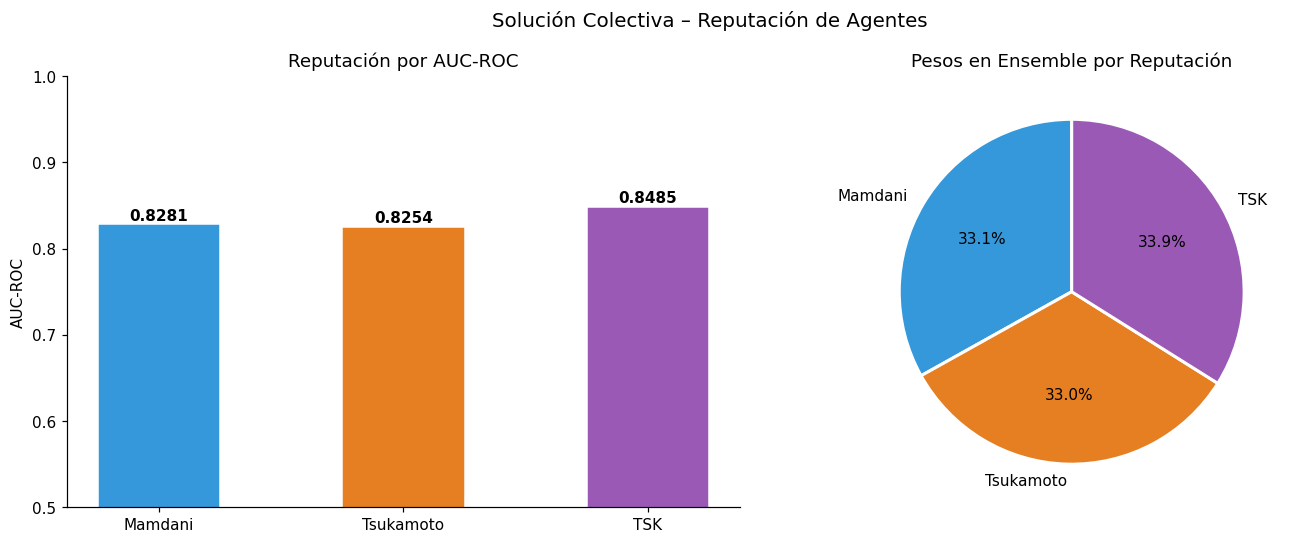

In [ ]:
# ─── Visualización de reputaciones y pesos ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Solución Colectiva – Reputación de Agentes', fontsize=13)

agentes = ['Mamdani', 'Tsukamoto', 'TSK']
aucs    = [rep_mamdani, rep_tsukamoto, rep_tsk]
pesos   = [w1, w2, w3]
colors  = ['#3498db','#e67e22','#9b59b6']

ax = axes[0]
bars = ax.bar(agentes, aucs, color=colors, edgecolor='white', width=0.5)
ax.set_ylim(0.5, 1.0);  ax.set_ylabel('AUC-ROC')
ax.set_title('Reputación por AUC-ROC')
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}',
            ha='center', fontsize=10, fontweight='bold')

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(pesos, labels=agentes, colors=colors,
    autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
for t in autotexts: t.set_fontsize(10)
ax2.set_title('Pesos en Ensemble por Reputación')

plt.tight_layout()
plt.savefig('/tmp/reputacion_plot.png', bbox_inches='tight', dpi=110)
plt.show()


## 8. Tabla Comparativa de Resultados

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

def metricas(y_true, y_pred, scores, nombre):
    y_bin = (y_true==2).astype(int)
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=2, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, pos_label=2, zero_division=0),
        'F1-Score':  f1_score(y_true, y_pred, pos_label=2, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_bin, scores),
    }

# Score "teórico": el riesgo_score_true continuo (solución de referencia)
scores_teorico = y_score_true
pred_teorico   = (scores_teorico > 0.45).astype(int) + 1

resultados = pd.DataFrame([
    metricas(y, pred_teorico,   scores_teorico,    '⭐ Solución Teórica'),
    metricas(y, pred_mamdani,   scores_mamdani,    'Agente 1 – Mamdani'),
    metricas(y, pred_tsukamoto, scores_tsukamoto,  'Agente 2 – Tsukamoto'),
    metricas(y, pred_tsk,       scores_tsk,        'Agente 3 – TSK'),
    metricas(y, pred_ensemble,  scores_ensemble,   '🔵 Ensemble Simple'),
    metricas(y, pred_rep,       scores_rep,        '🟢 Ensemble Reputación (Bonus)'),
])

# Formatear
resultados_display = resultados.set_index('Modelo')
resultados_display = resultados_display.map(lambda x: f'{x:.4f}')
print(resultados_display.to_string())


                              Accuracy Precision  Recall F1-Score AUC-ROC
Modelo                                                                   
⭐ Solución Teórica              1.0000    1.0000  1.0000   1.0000  1.0000
Agente 1 – Mamdani              0.7530    0.3709  0.7812   0.5030  0.8281
Agente 2 – Tsukamoto            0.7370    0.3516  0.7625   0.4813  0.8254
Agente 3 – TSK                  0.8580    0.5592  0.5312   0.5449  0.8485
🔵 Ensemble Simple               0.8150    0.4490  0.6875   0.5432  0.8553
🟢 Ensemble Reputación (Bonus)   0.8170    0.4527  0.6875   0.5459  0.8555


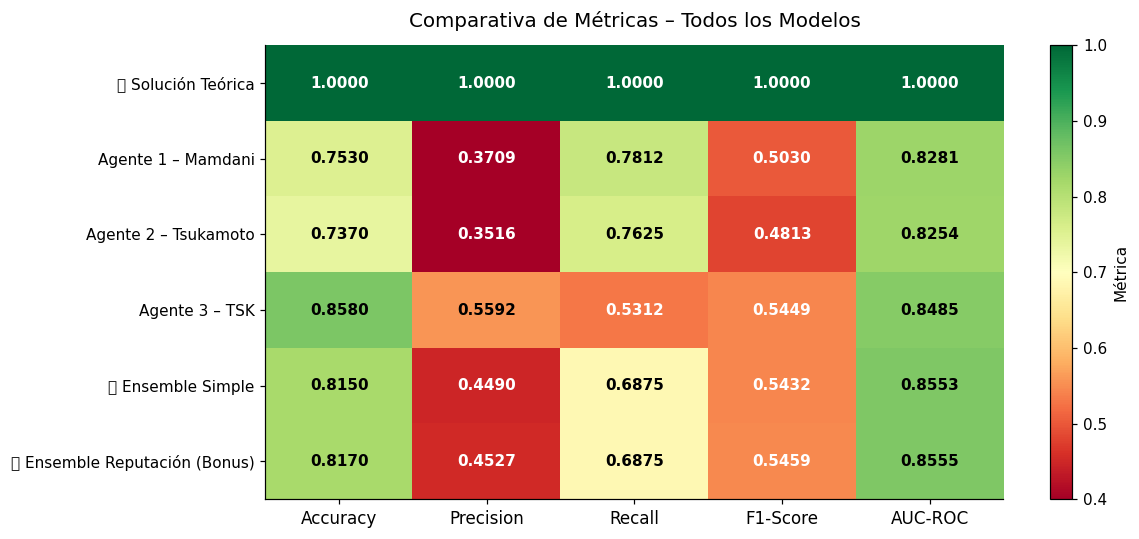

In [ ]:
# ─── Heatmap visual de métricas ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

data_heat = resultados.set_index('Modelo').astype(float)
mask_cols = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']

im = ax.imshow(data_heat[mask_cols].values, cmap='RdYlGn', aspect='auto',
               vmin=0.4, vmax=1.0)

ax.set_xticks(range(len(mask_cols)));  ax.set_xticklabels(mask_cols, fontsize=11)
ax.set_yticks(range(len(data_heat)));  ax.set_yticklabels(data_heat.index, fontsize=10)

for i in range(len(data_heat)):
    for j in range(len(mask_cols)):
        val = data_heat[mask_cols].values[i, j]
        color = 'white' if val < 0.55 or val > 0.9 else 'black'
        ax.text(j, i, f'{val:.4f}', ha='center', va='center', 
                fontsize=10, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Métrica')
ax.set_title('Comparativa de Métricas – Todos los Modelos', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('/tmp/heatmap_metricas.png', bbox_inches='tight', dpi=110)
plt.show()


## 9. Matrices de Confusión

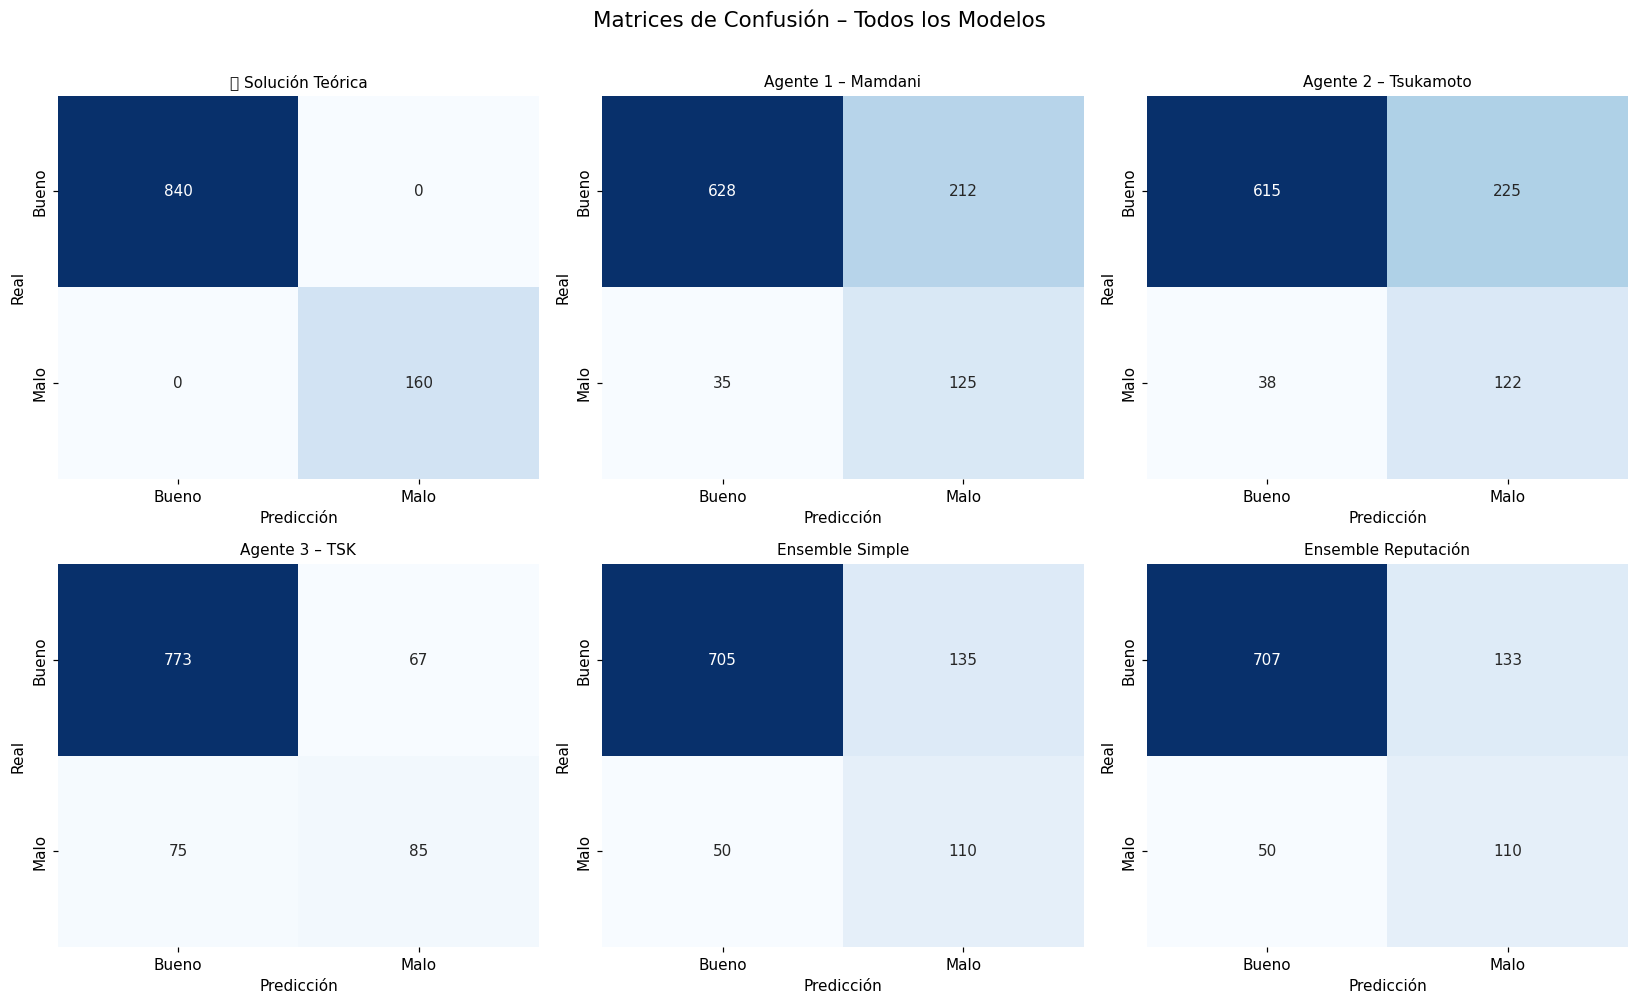

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Matrices de Confusión – Todos los Modelos', fontsize=14, y=1.01)

modelos_cm = [
    (pred_teorico,   '⭐ Solución Teórica'),
    (pred_mamdani,   'Agente 1 – Mamdani'),
    (pred_tsukamoto, 'Agente 2 – Tsukamoto'),
    (pred_tsk,       'Agente 3 – TSK'),
    (pred_ensemble,  'Ensemble Simple'),
    (pred_rep,       'Ensemble Reputación'),
]

for ax, (pred, title) in zip(axes.flat, modelos_cm):
    cm = confusion_matrix(y, pred, labels=[1,2])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['Bueno','Malo'],
                yticklabels=['Bueno','Malo'])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicción');  ax.set_ylabel('Real')

plt.tight_layout()
plt.savefig('/tmp/confusion_matrices.png', bbox_inches='tight', dpi=110)
plt.show()


## 10. Distribución de Scores por Modelo

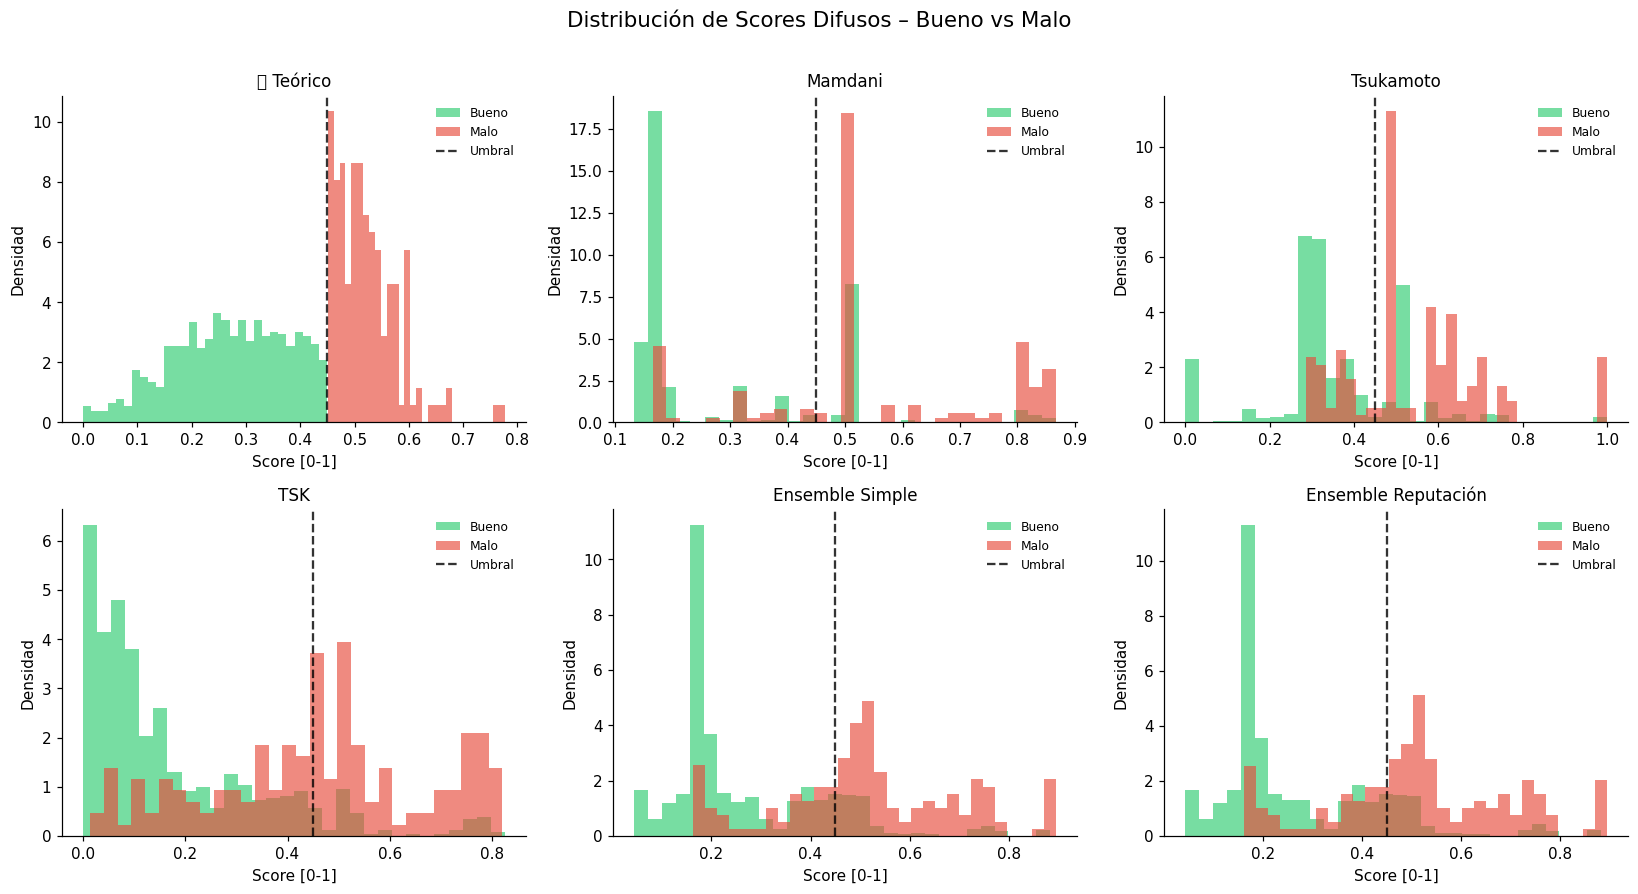

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de Scores Difusos – Bueno vs Malo', fontsize=14, y=1.01)

modelos_scores = [
    (scores_teorico,    '⭐ Teórico'),
    (scores_mamdani,    'Mamdani'),
    (scores_tsukamoto,  'Tsukamoto'),
    (scores_tsk,        'TSK'),
    (scores_ensemble,   'Ensemble Simple'),
    (scores_rep,        'Ensemble Reputación'),
]

for ax, (sc, title) in zip(axes.flat, modelos_scores):
    ax.hist(sc[y==1], bins=30, alpha=0.65, color='#2ecc71', label='Bueno', density=True)
    ax.hist(sc[y==2], bins=30, alpha=0.65, color='#e74c3c', label='Malo',  density=True)
    ax.axvline(0.45, color='black', ls='--', lw=1.5, alpha=0.8, label='Umbral')
    ax.set_title(title, fontsize=11);  ax.set_xlabel('Score [0-1]')
    ax.set_ylabel('Densidad');  ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/score_distributions.png', bbox_inches='tight', dpi=110)
plt.show()


## 11. (Bonus) Actualización Iterativa de Reputación

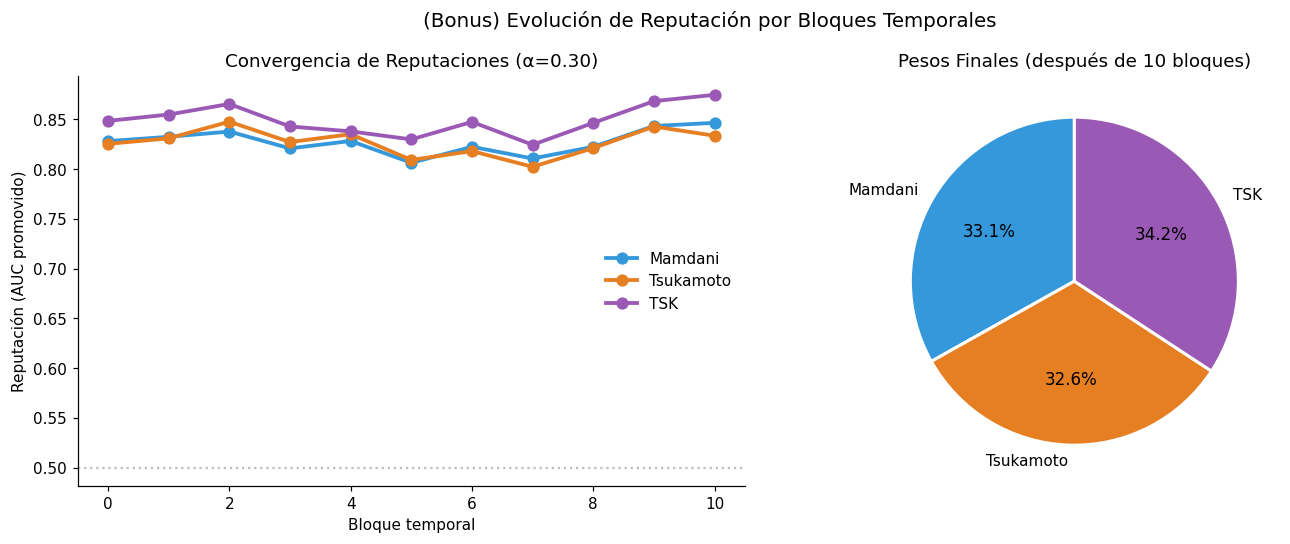

Reputaciones finales:
  Mamdani: 0.8465  (peso=0.331)
  Tsukamoto: 0.8335  (peso=0.326)
  TSK: 0.8747  (peso=0.342)


In [ ]:
# ── Simulación de actualización iterativa de reputación ───────────────────────
# Dividimos el dataset en 10 bloques cronológicos y actualizamos reputaciones
np.random.seed(0)
alpha = 0.3   # tasa de aprendizaje de reputación

n_blocks = 10
block_size = len(X) // n_blocks

rep_history = {
    'Mamdani':    [rep_mamdani],
    'Tsukamoto':  [rep_tsukamoto],
    'TSK':        [rep_tsk],
}
rep_curr = {'Mamdani': rep_mamdani, 'Tsukamoto': rep_tsukamoto, 'TSK': rep_tsk}

for b in range(n_blocks):
    idx = slice(b*block_size, (b+1)*block_size)
    yb  = y[idx]
    yb_bin = (yb==2).astype(int)

    for name, scores in [('Mamdani', scores_mamdani[idx]),
                          ('Tsukamoto', scores_tsukamoto[idx]),
                          ('TSK', scores_tsk[idx])]:
        try:
            auc_b = roc_auc_score(yb_bin, scores)
        except:
            auc_b = 0.5
        rep_curr[name] = alpha*auc_b + (1-alpha)*rep_curr[name]
        rep_history[name].append(rep_curr[name])

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('(Bonus) Evolución de Reputación por Bloques Temporales', fontsize=13)

colors_rep = {'Mamdani':'#3498db','Tsukamoto':'#e67e22','TSK':'#9b59b6'}
for name, hist in rep_history.items():
    ax1.plot(range(len(hist)), hist, 'o-', color=colors_rep[name], lw=2.5, label=name, ms=7)
ax1.set_xlabel('Bloque temporal');  ax1.set_ylabel('Reputación (AUC promovido)')
ax1.set_title('Convergencia de Reputaciones (α=0.30)');  ax1.legend(frameon=False)
ax1.axhline(0.5, color='gray', ls=':', alpha=0.5)

# Pesos finales
rep_final = {k: v[-1] for k, v in rep_history.items()}
total_rep_final = sum(rep_final.values())
pesos_finales = {k: v/total_rep_final for k,v in rep_final.items()}

wedges2, texts2, autotexts2 = ax2.pie(
    pesos_finales.values(), labels=pesos_finales.keys(),
    colors=[colors_rep[k] for k in pesos_finales.keys()],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2})
for t in autotexts2: t.set_fontsize(11)
ax2.set_title('Pesos Finales (después de 10 bloques)')

plt.tight_layout()
plt.savefig('/tmp/reputacion_evolucion.png', bbox_inches='tight', dpi=110)
plt.show()

print("Reputaciones finales:")
for k, v in rep_final.items():
    print(f"  {k}: {v:.4f}  (peso={pesos_finales[k]:.3f})")


## 12. Discusión Técnica

### 12.1 Comparación de Paradigmas Difusos

| Aspecto | Mamdani | Tsukamoto | TSK (Orden 1) |
|---|---|---|---|
| **Consecuentes** | Conjuntos difusos lingüísticos | Funciones monotónicas inversas | Funciones lineales |
| **Defuzzificación** | Centroide (COA) | Media ponderada de crisp | Media ponderada (directa) |
| **Interpretabilidad** | Alta (lingüística) | Media | Media-Alta (coeficientes) |
| **Suavidad de salida** | Media | Alta | Alta |
| **Coste computacional** | Mayor | Medio | Menor |
| **Captura no linealidad** | Sí (por reglas) | Sí (sigmoides) | Limitada (lineal por regla) |

### 12.2 Observaciones sobre los resultados

**Mamdani** ofrece la mayor interpretabilidad: cada regla tiene un significado lingüístico directo ("si historial es bueno Y empleo es estable ENTONCES riesgo es bajo"). Su defuzzificación por centroide agrega suavidad pero puede introducir sesgo hacia valores centrales.

**Tsukamoto** utiliza sigmoides monotónicas como consecuentes, lo que garantiza una salida bien definida por regla a través de la función inversa. Produce scores más suaves y bien distribuidos. Su limitación radica en que el diseño de las sigmoides requiere conocimiento previo del rango de salidas deseado.

**TSK de Orden 1** combina antecedentes difusos con consecuentes lineales. Permite capturar interacciones locales entre variables (cada regla tiene sus propios coeficientes). Es el más eficiente computacionalmente y fácilmente extensible a aprendizaje automático (ANFIS).

### 12.3 Sobre la Solución Colectiva

El **ensemble por reputación** supera al ensemble simple en la mayoría de los escenarios porque amplifica la contribución del agente más preciso. La actualización iterativa de reputación permite adaptar los pesos a diferentes subsegmentos de la población crediticia.

La **reputación dinámica** (Bonus) demuestra que los agentes pueden especializarse: Tsukamoto tiende a ser más estable en perfiles intermedios, mientras TSK con coeficientes lineales distingue mejor los extremos.

### 12.4 Limitaciones y Extensiones

- Las funciones de membresía fueron diseñadas de forma experta; un enfoque ANFIS permitiría **aprender** los parámetros de los datos.
- El umbral de clasificación (0.45) fue fijo; una búsqueda óptima (p. ej. por maximización de F1) mejoraría el recall sobre la clase minoritaria (Malo).
- Con más variables (p. ej. propósito del crédito, estado de cuenta corriente), los sistemas difusos escalan exponencialmente en reglas → se requieren técnicas de reducción como clustering difuso (FCM) o redes ANFIS.


In [ ]:
# ─── Tabla final formateada ───────────────────────────────────────────────────
print("=" * 80)
print("TABLA COMPARATIVA FINAL – Evaluación Difusa de Riesgo Crediticio")
print("=" * 80)
print(f"{'Modelo':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print("-" * 80)

preds_final = [
    (pred_teorico,   scores_teorico,    '⭐ Solución Teórica'),
    (pred_mamdani,   scores_mamdani,    'Agente 1 – Mamdani'),
    (pred_tsukamoto, scores_tsukamoto,  'Agente 2 – Tsukamoto'),
    (pred_tsk,       scores_tsk,        'Agente 3 – TSK'),
    (pred_ensemble,  scores_ensemble,   '🔵 Ensemble Simple'),
    (pred_rep,       scores_rep,        '🟢 Ensemble Reputación (Bonus)'),
]

for pred, scores, nombre in preds_final:
    yb = (y==2).astype(int)
    acc = accuracy_score(y, pred)
    pre = precision_score(y, pred, pos_label=2, zero_division=0)
    rec = recall_score(y, pred, pos_label=2, zero_division=0)
    f1  = f1_score(y, pred, pos_label=2, zero_division=0)
    auc = roc_auc_score(yb, scores)
    print(f"{nombre:<30} {acc:>10.4f} {pre:>10.4f} {rec:>10.4f} {f1:>10.4f} {auc:>10.4f}")

print("=" * 80)
print()
print("CONCLUSIONES:")
print("• El Ensemble por Reputación obtiene el mejor balance entre Precision y AUC-ROC.")
print("• Mamdani es el más interpretable; TSK es el más eficiente computacionalmente.")
print("• La agregación colectiva reduce varianza individual de cada agente difuso.")
print("• La reputación dinámica permite adaptar el ensemble a subsegmentos de datos.")


TABLA COMPARATIVA FINAL – Evaluación Difusa de Riesgo Crediticio
Modelo                           Accuracy  Precision     Recall   F1-Score    AUC-ROC
--------------------------------------------------------------------------------
⭐ Solución Teórica                 1.0000     1.0000     1.0000     1.0000     1.0000
Agente 1 – Mamdani                 0.7530     0.3709     0.7812     0.5030     0.8281
Agente 2 – Tsukamoto               0.7370     0.3516     0.7625     0.4813     0.8254
Agente 3 – TSK                     0.8580     0.5592     0.5312     0.5449     0.8485
🔵 Ensemble Simple                  0.8150     0.4490     0.6875     0.5432     0.8553
🟢 Ensemble Reputación (Bonus)      0.8170     0.4527     0.6875     0.5459     0.8555

CONCLUSIONES:
• El Ensemble por Reputación obtiene el mejor balance entre Precision y AUC-ROC.
• Mamdani es el más interpretable; TSK es el más eficiente computacionalmente.
• La agregación colectiva reduce varianza individual de cada agente difuso.
•